
# VQ‑VNS Demo: Single‑Subject Inference (T1 MRI)

This notebook walks through a **complete demo** of the single‑subject pipeline:

1. **Configure** inputs/paths  
2. **Preprocess** the MRI (calls your `generic_t1_preprocess.py`)  
3. **Preview** axial, sagittal, coronal slices with consistent orientation  
4. **Run inference** with `infer_single_subject.py`  

> **Note:** This demo assumes your repository structure and scripts are already available
> in the current working directory (e.g., `generic_t1_preprocess.py`, `infer_single_subject.py`,
> and `reference_data/` templates).


# 0) Create environment and import packages and download weights

## Environment Setup

Before running this notebook, please ensure that you have created and activated the required Conda environment:

```bash
conda env create -f environment.yml
conda activate vqvns_env


In [1]:
import os
import numpy as np
import subprocess
import nibabel as nib
from matplotlib import pyplot as plt

Download weights from https://huggingface.co/hsuresh/vqvns and place into the weights folder inside the demo folder

# 1) Configuration

In [ ]:
# --- User-configurable paths ---
MRI_PATH = "example_patient.nii.gz"  # "/path/to/your/mri_file.nii.gz"
PROCESSED_DIR = "output"

# Create output dir if needed
os.makedirs(PROCESSED_DIR, exist_ok=True)

In [3]:
# Reference templates
dbm_template_img_path = 'reference_data/dbm_template.nii.gz'
mni_template_img_path = 'reference_data/MNI152_T1_1mm_brain.nii.gz'


# Create output dir if needed
os.makedirs(PROCESSED_DIR, exist_ok=True)

print("MRI_PATH:", MRI_PATH)
print("PROCESSED_DIR:", PROCESSED_DIR)
for p in [dbm_template_img_path, mni_template_img_path]:
    print(f"Exists({p}):", os.path.exists(p))

MRI_PATH: synthetic_responder.nii.gz
PROCESSED_DIR: output
Exists(reference_data/dbm_template.nii.gz): True
Exists(reference_data/MNI152_T1_1mm_brain.nii.gz): True


# 2) Preprocess MRI

In [4]:
preprocess_cmd = f"python generic_t1_preprocess.py -i {MRI_PATH} -o {PROCESSED_DIR}"
print("Running:", preprocess_cmd)
try:
    result = subprocess.run(preprocess_cmd, shell=True, check=True, capture_output=True, text=True)
    print("Preprocessing complete.")
    if result.stderr.strip():
        print("\n--- STDERR ---")
        print(result.stderr)
except subprocess.CalledProcessError as e:
    print("Preprocessing failed.")
    print(e.stdout or "")
    print(e.stderr or "")
    raise

# Try to find last emitted .nii.gz path from stdout and confirm it exists
cropped_path = None
for line in (result.stdout or "").splitlines()[::-1]:
    c = line.strip()
    if c.endswith(".nii.gz") and os.path.exists(c):
        cropped_path = c
        break

if not cropped_path:
    # Fall back to scanning PROCESSED_DIR for a recent NIfTI
    cands = [os.path.join(PROCESSED_DIR, f) for f in os.listdir(PROCESSED_DIR) if f.endswith(".nii.gz")]
    cands = sorted(cands, key=os.path.getmtime, reverse=True)
    if cands:
        cropped_path = cands[0]

if not cropped_path:
    raise FileNotFoundError("Cropped file not found. Check preprocessing outputs.")

print("Using preprocessed/cropped file:", cropped_path)


Running: python generic_t1_preprocess.py -i synthetic_responder.nii.gz -o output
Preprocessing complete.
Using preprocessed/cropped file: output/fcm_mni_reg_cropped/synthetic_responder.nii.gz


# 3) Visualize slices

Post-processing image slices:


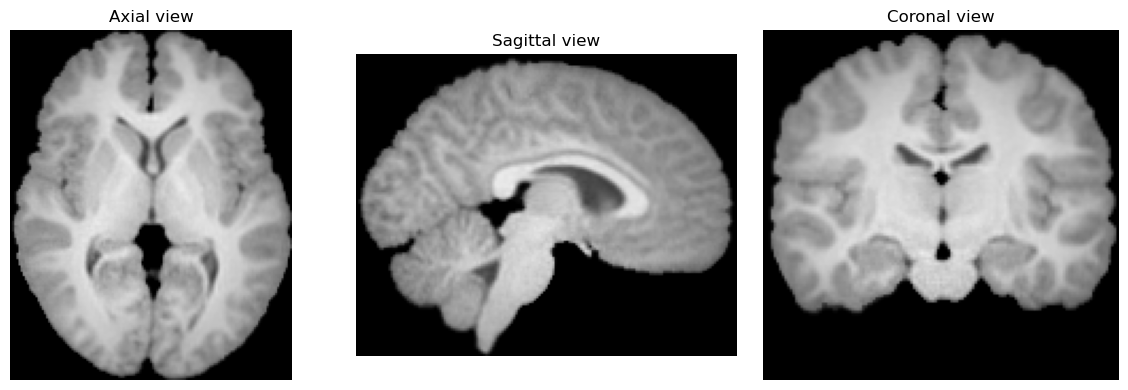

In [5]:
try:
    img = nib.load(cropped_path)
    data = img.get_fdata()

    # Select slices
    axial_slice = data[:, :, data.shape[2] // 2]
    sagittal_slice = data[data.shape[0] // 2 + 5, :, :]
    coronal_slice = data[:, data.shape[1] // 2, :]

    print("Post-processing image slices:")

    # Create figure
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    # Plot Axial view (flipped vertically)
    axes[0].imshow(np.flipud(np.rot90(axial_slice)), cmap='gray', origin='lower', vmin=0, vmax=1.3)
    axes[0].set_title("Axial view")
    axes[0].axis('off')

    # Plot Sagittal view (flipped vertically)
    axes[1].imshow(np.flipud(np.rot90(sagittal_slice)), cmap='gray', origin='lower', vmin=0, vmax=1.3)
    axes[1].set_title("Sagittal view")
    axes[1].axis('off')

    # Plot Coronal view (flipped vertically)
    axes[2].imshow(np.flipud(np.rot90(coronal_slice)), cmap='gray', origin='lower', vmin=0, vmax=1.3)
    axes[2].set_title("Coronal view")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Could not display image slice: {e}")


# 4) Run inference

In [7]:
print("Running inference...")
infer_cmd = f"python infer_single_subject.py --mri {cropped_path}"
try:
    result = subprocess.run(infer_cmd, shell=True, check=True, capture_output=True, text=True)
    output = result.stdout
    print("Inference complete.")
except subprocess.CalledProcessError as e:
    print(f"Inference failed: {e.stderr if e.stderr else e}")
    exit(1)
    
# Parse prediction
if "Responder" in output:
    pred = "Responder"
    print(f"Prediction: {pred}")
elif "Non-responder" in output:
    pred = "Non-responder"
    print(f"Prediction: {pred}")
else:
    pred = "Unknown"
    print("Could not determine prediction from output.")

# output the prediction result
from IPython.display import HTML, display
import os

color = "#16a34a" if pred == "Responder" else ("#dc2626" if pred == "Non-responder" else "#6b7280")
msg = ("""
<div style="padding:16px;border-radius:12px;border:1px solid #e5e7eb;
            font-family:ui-sans-serif,system-ui,Segoe UI,Helvetica,Arial;
            background:#f9fafb;">
  <div style="font-size:14px;color:#374151;margin-bottom:6px;">VQ‑VNS Single‑Subject Inference</div>
  <div style="font-size:28px;font-weight:700;color:%s;">
    %s
  </div>
  <div style="font-size:12px;color:#6b7280;margin-top:8px;">
    MRI file: <code>%s</code>
  </div>
</div>
""" % (color, pred, os.path.basename(cropped_path)))
display(HTML(msg))


Running inference...
Inference complete.
Prediction: Responder
